In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import timeit

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

In [ ]:
# Define the Gaussian method
def random_direction(n):
    vec = np.random.normal(0, 1, n+1)
    norm = np.linalg.norm(vec)
    unit_vec = vec / norm
    return unit_vec

In [ ]:
# Define the Rejection method
def random_direction_rejection(n):
    while True:
        point = np.random.uniform(-1, 1, n+1)
        if np.linalg.norm(point) <= 1:
            return point / np.linalg.norm(point)

In [6]:
# Benchmarking setup
ns = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Different dimensions to test
number_of_runs = 1000  # Number of runs for each test to average out the time

benchmark_results = {}

for n in ns:
    gaussian_time = timeit.timeit('random_direction(n)', globals=globals(), number=number_of_runs)
    rejection_time = timeit.timeit('random_direction_rejection(n)', globals=globals(), number=number_of_runs)
    benchmark_results[n] = (gaussian_time, rejection_time)

benchmark_results

{1: (0.0074541999492794275, 0.023625799920409918),
 2: (0.005754400044679642, 0.017252800054848194),
 3: (0.006293700076639652, 0.023864699993282557),
 4: (0.00670010014437139, 0.04146540001966059),
 5: (0.006444600177928805, 0.07589169987477362),
 6: (0.005454099969938397, 0.14906159997917712),
 7: (0.005530599970370531, 0.34781150007620454),
 8: (0.005618700059130788, 0.8564341999590397),
 9: (0.005622400203719735, 2.204591700108722),
 10: (0.005566600011661649, 5.891162199899554)}

In [11]:
results_df = pd.DataFrame(benchmark_results).T
results_df.columns = ['Gaussian', 'Rejection']
results_df['Ratio'] = results_df['Rejection'] / results_df['Gaussian']
results_df

,Gaussian,Rejection,Ratio
1,0.007454,0.023626,3.169462
2,0.005754,0.017253,2.998193
3,0.006294,0.023865,3.791839
4,0.006700,0.041465,6.188773
5,0.006445,0.075892,11.776014
6,0.005454,0.149062,27.330192
7,0.005531,0.347812,62.888566
8,0.005619,0.856434,152.425684
9,0.005622,2.204592,392.108640
10,0.005567,5.891162,1058.305283


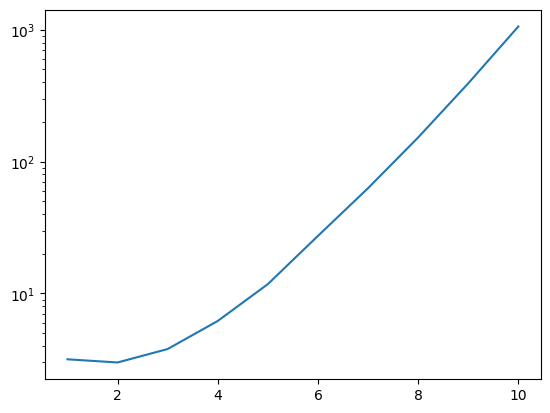

In [15]:
results_df['Ratio'].plot()
plt.yscale('log')

In [16]:
import numpy as np
from scipy.special import gamma

def dot_product_pdf(z, n):
    """
    Calculate the PDF of the dot product between two randomly chosen points
    on an n-sphere.
    
    Parameters:
    - z: The dot product between two points on the n-sphere.
    - n: The dimension of the sphere.
    
    Returns:
    - The value of the PDF at the given dot product z.
    """
    if z < -1 or z > 1:
        return 0  # The dot product is outside the valid range.
    coefficient = 1 / np.sqrt(np.pi) * gamma(n / 2) / gamma((n - 1) / 2)
    pdf_value = coefficient * (1 - z**2)**((n - 3) / 2)
    return pdf_value

# Example usage:
z = 0.5  # Example dot product
n = 4    # Dimension of the sphere
pdf_value = dot_product_pdf(z, n)
print(f"PDF value for z={z} on an {n}-sphere: {pdf_value}")


PDF value for z=0.5 on an 4-sphere: 0.5513288954217921


C:\Users\olooney\AppData\Local\Temp\ipykernel_19448\876149586.py:19: RuntimeWarning: divide by zero encountered in scalar power
  pdf_value = coefficient * (1 - z**2)**((n - 3) / 2)
C:\Users\olooney\AppData\Local\Temp\ipykernel_19448\876149586.py:19: RuntimeWarning: invalid value encountered in scalar multiply
  pdf_value = coefficient * (1 - z**2)**((n - 3) / 2)


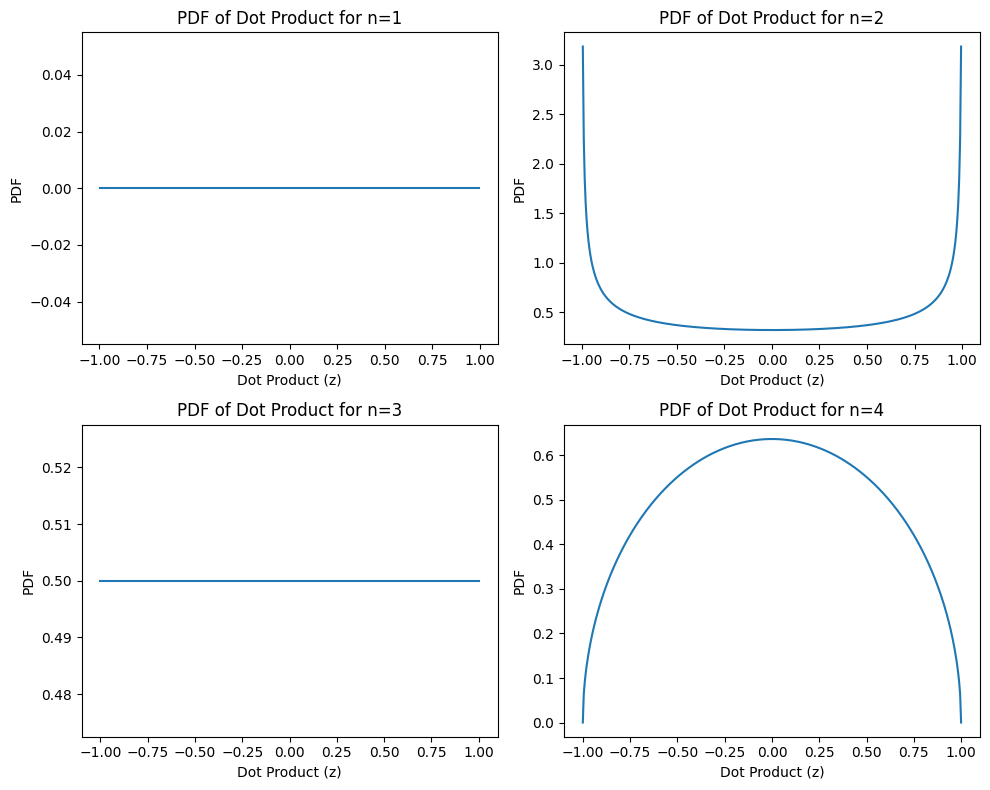

In [20]:
# Define z range
z_values = np.linspace(-1, 1, 400)

# Plot setup
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ns = [1, 2, 3, 4]
for i, n in enumerate(ns):
    ax = axs[i // 2, i % 2]
    pdf_values = [dot_product_pdf(z, n) for z in z_values]
    ax.plot(z_values, pdf_values, label=f'n = {n}')
    ax.set_title(f'PDF of Dot Product for n={n}')
    ax.set_xlabel('Dot Product (z)')
    ax.set_ylabel('PDF')

plt.tight_layout()
plt.show()

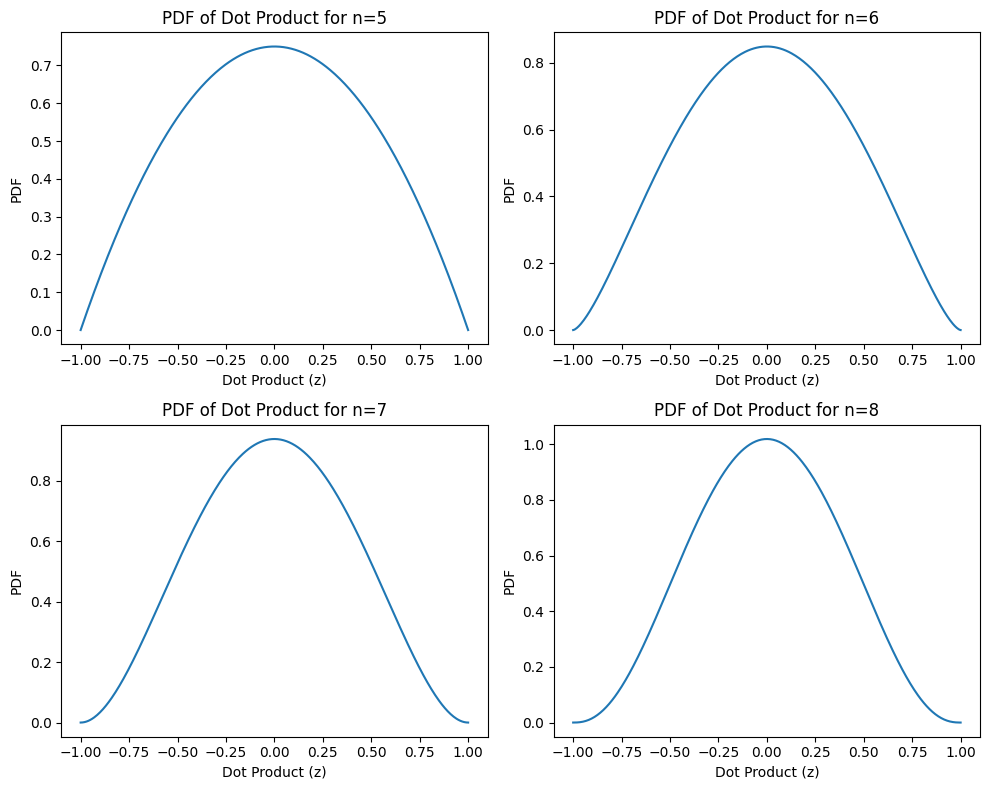

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ns = [5, 6, 7, 8]
for i, n in enumerate(ns):
    ax = axs[i // 2, i % 2]
    pdf_values = [dot_product_pdf(z, n) for z in z_values]
    ax.plot(z_values, pdf_values, label=f'n = {n}')
    ax.set_title(f'PDF of Dot Product for n={n}')
    ax.set_xlabel('Dot Product (z)')
    ax.set_ylabel('PDF')

plt.tight_layout()
plt.show()

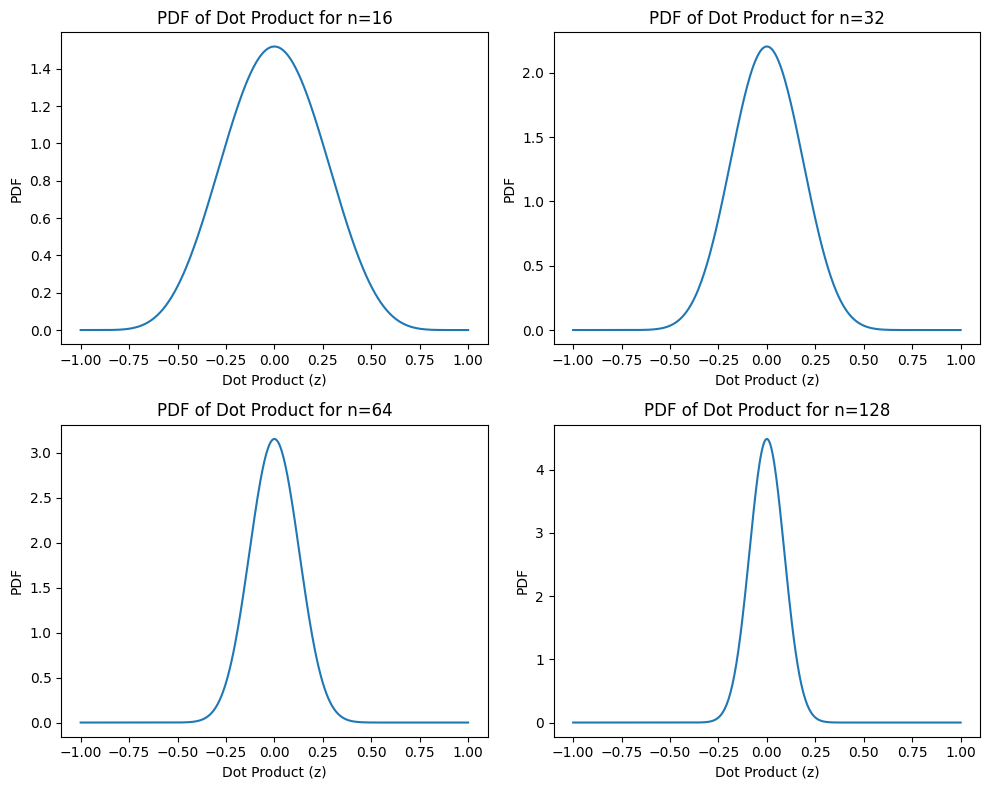

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ns = [16, 32, 64, 128]
for i, n in enumerate(ns):
    ax = axs[i // 2, i % 2]
    pdf_values = [dot_product_pdf(z, n) for z in z_values]
    ax.plot(z_values, pdf_values, label=f'n = {n}')
    ax.set_title(f'PDF of Dot Product for n={n}')
    ax.set_xlabel('Dot Product (z)')
    ax.set_ylabel('PDF')

plt.tight_layout()
plt.show()

In [57]:
def generate_multivariate_normal_data_from_scratch(sigma, num_samples=100):
    """
    Generate synthetic data from a multivariate normal distribution using Cholesky decomposition.
    
    Parameters:
    - sigma: Covariance matrix (2D array).
    - num_samples: Number of samples to generate.
    
    Returns:
    - samples: Generated samples as a 2D array (num_samples x dimension of sigma).
    """
    # Step 1: Compute the Cholesky Decomposition of sigma
    L = np.linalg.cholesky(sigma)
    
    # Step 2: Generate standard normal samples
    dim = sigma.shape[0]  # Dimensionality of the distribution
    standard_normal_samples = np.random.normal(0, 1, (num_samples, dim))
    
    # Step 3: Transform the standard normal samples
    samples = standard_normal_samples @ L.T  # Matrix multiplication
    
    return samples

# Example usage
sigma = np.array([[1, 0.5], [0.5, 1]])  # Example covariance matrix
num_samples = 1000  # Number of samples to generate

samples = generate_multivariate_normal_data_from_scratch(sigma, num_samples)

# Display the first few samples
print(samples[:5])


[[ 0.48264709  0.98110769]
 [ 0.05109113 -1.5202616 ]
 [-0.48636012  0.12499598]
 [-0.07092824  0.38859153]
 [ 0.64431012 -0.13900439]]


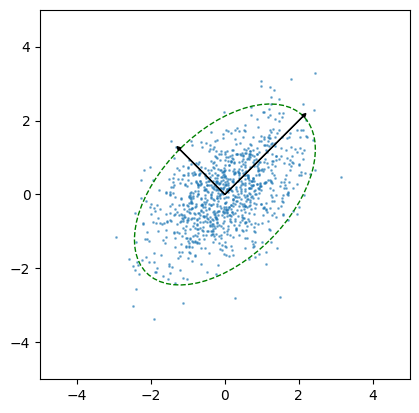

In [280]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import stats

def g(sigma, num_samples=100):
    # sigma is a square covariance matrix
    L = np.linalg.cholesky(sigma)
    dim = sigma.shape[0]  # Dimensionality of the distribution
    standard_normal_samples = np.random.normal(0, 1, (num_samples, dim))
    samples = standard_normal_samples @ L.T  # Matrix multiplication
    return samples

def plot_samples_with_ellipse(samples, sigma, ax=None, alpha=0.95):
    """
    Plot the samples as a 2D scatterplot and add the ellipse for the given confidence interval.

    Parameters:
    - samples: Array of shape (num_samples, 2) containing the generated samples.
    - sigma: Covariance matrix of shape (2, 2).
    - ax: Matplotlib Axes object to plot on. If None, a new figure will be created.
    - alpha: Confidence interval level.
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Plot the samples as a scatterplot
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)

    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eig_vals, eig_vecs = np.linalg.eig(sigma)

    # Calculate the radius for the ellipse
    chi2_inv = stats.chi2.ppf(alpha, df=2)
    radius = np.sqrt(chi2_inv * eig_vals)

    # Calculate the angle of rotation for the ellipse
    angle = np.degrees(np.arctan2(eig_vecs[1, 0], eig_vecs[0, 0]))

    # Create the ellipse
    ellipse = Ellipse(xy=(0, 0), width=2 * radius[0], height=2 * radius[1], angle=angle, edgecolor='g', ls='--', lw=1, fc='None')

    # Add the ellipse to the plot
    ax.add_artist(ellipse)

    # Add arrows for the eigenvectors
    arrow_scalings = np.sqrt(5.991 * eig_vals)
    for i in range(2):
        arrow_start = (0, 0)
        arrow_end = arrow_scalings[i] * eig_vecs[:, i]
        ax.arrow(*arrow_start, *arrow_end, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1)

    # Set the plot limits and aspect ratio
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')

    plt.show()

# Example usage
sigma = np.array([[1, 0.5], [0.5, 1]])
num_samples = 1000
samples = g(sigma, num_samples)
plot_samples_with_ellipse(samples, sigma)

In [61]:
empirical_covariance = np.cov(samples, rowvar=False)
empirical_covariance

array([[1.00049589, 0.47751021],
       [0.47751021, 0.96528366]])

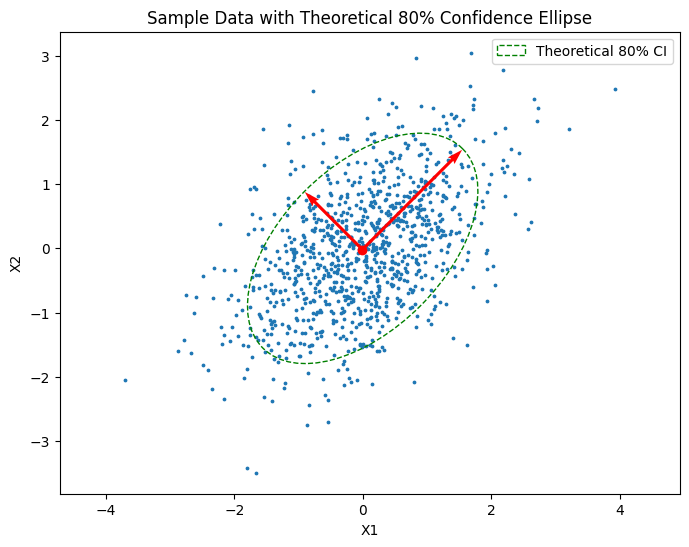

In [65]:
# 5.991 corresponds to 95% CI for 2 degrees of freedom
alpha = 0.2
chi_squared_critical_value = chi2.ppf(1-alpha, 2)

# Calculate the eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(sigma)

# Calculate the angle of rotation of the ellipse
angle = np.arctan2(*eigenvectors[:, 0][::-1])

# Calculate width and height of the ellipse based on eigenvalues
# The eigenvalues give the length of the ellipse axes (square root of the eigenvalues gives the standard deviation)
width, height = 2 * np.sqrt(eigenvalues * chi_squared_critical_value)

# Create an ellipse representing the theoretical 95% CI of the distribution
ellipse = Ellipse(
    xy=(0, 0),
    width=width,
    height=height,
    angle=np.degrees(angle),
    edgecolor='g',
    linestyle='dashed',
    fc='None',
    lw=1,
    label=f'Theoretical {(1-alpha)*100:2.0f}% CI')

# Plot the sample data
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=3)

# Plot the ellipse
plt.gca().add_patch(ellipse)

# Highlight the mean of the samples
mean = np.mean(samples, axis=0)
plt.plot(mean[0], mean[1], 'ro')  # Plot the mean as a red dot

for i in range(2):
    vec_end = mean + np.sqrt(chi_squared_critical_value) * np.sqrt(eigenvalues[i]) * eigenvectors[:, i]
    plt.quiver(*mean, *(vec_end-mean), angles='xy', scale_units='xy', scale=1, color='red', width=0.005, zorder=5)
    # , label=f'$e_{i+1}$'

# Calculate fraction of points inside the ellipse
transformed_samples = (samples - mean) @ eigenvectors / np.sqrt(eigenvalues)  # Normalize by eigenvalues
distances_squared = np.sum(transformed_samples**2, axis=1)
inside_count = np.sum(distances_squared <= chi_squared_critical_value)
fraction_inside = inside_count / num_samples
fraction_inside

plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Sample Data with Theoretical {(1-alpha)*100:2.0f}% Confidence Ellipse')
plt.legend()
plt.axis('equal')
plt.show()

In [4]:
def chebyshev_nodes(a, b, n):
    """
    Calculate n+1 Chebyshev nodes for the interval [a, b].
    
    Parameters:
    - a: Lower bound of the interval.
    - b: Upper bound of the interval.
    - n: Degree of the polynomial.
    
    Returns:
    - An array of n+1 Chebyshev nodes.
    """
    i = np.arange(n+1)
    x = np.cos((2*i+1) * np.pi / (2*n+2))  # Chebyshev nodes in [-1, 1]
    return 0.5 * ((b-a) * x + a + b)  # Map nodes to [a, b]

# Example usage:
nodes = chebyshev_nodes(a=0, b=5, n=4)
print("Chebyshev nodes:", nodes)


Chebyshev nodes: [4.87764129 3.96946313 2.5        1.03053687 0.12235871]


[-1.92145227e-07  3.42878255e-06 -1.36752727e-06 -1.96660296e-04
 -1.45933598e-06  8.33412223e-03 -2.69162358e-07 -1.66666612e-01
 -5.82339432e-09  1.00000000e+00 -2.42687994e-12]
-9.39079097860391e-13


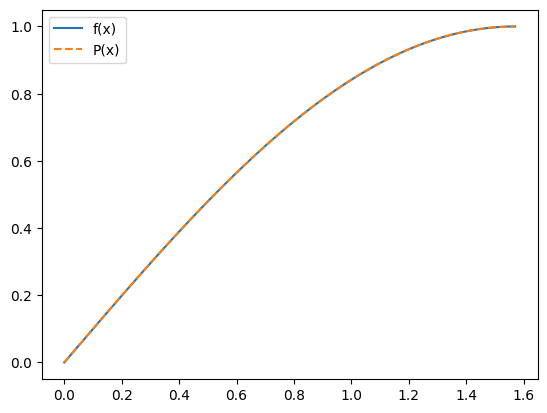

In [262]:
def remez_approximation(f, bounds, n):
    # Step 1: Choose n+2 sample points
    # x_points = np.linspace(bounds[0], bounds[1], n+2)
    x_points = chebyshev_nodes(bounds[0], bounds[1], n+1)
    
    # Step 2: Create the matrix A and vector b
    A = np.zeros((n+2, n+2))
    b = np.zeros(n+2)
    for i, x in enumerate(x_points):
        A[i, :-1] = [x**k for k in range(n+1)]
        A[i, -1] = (-1)**i
        b[i] = f(x)
    
    # Step 3: Solve the system of equations Ap = b
    p = np.linalg.solve(A, b)
    
    # Define the closure for polynomial evaluation
    def P(x):
        return np.polyval(p[:-1][::-1], x)
    
    return p[:-1][::-1], p[-1], P

# Example usage:
def f(x):
    return np.sin(x)  # Example function

bounds = [0, np.pi/2]  # Approximation bounds
n = 10  # Degree of the polynomial

p, E, P = remez_approximation(f, bounds, n)
print(p)
print(E)

# Evaluate and plot
import matplotlib.pyplot as plt
x_vals = np.linspace(bounds[0], bounds[1], 1000)
plt.plot(x_vals, f(x_vals), label='f(x)')
plt.plot(x_vals, P(x_vals), label='P(x)', linestyle='--')
plt.legend()


In [263]:
def format_polynomial(coeffs):
    """
    Format a list of polynomial coefficients as a polynomial string.
    
    Parameters:
    - coeffs: A list or array of coefficients in descending order.
    
    Returns:
    - A string representing the polynomial.
    """
    terms = []
    n = len(coeffs)
    
    for i, coeff in enumerate(coeffs):
        power = n - i - 1  # Calculate the power of x for the current coefficient
        
        # Skip zero coefficients
        if coeff == 0:
            continue
        
        # Handle the sign (+/-), except for the leading term
        sign = '-' if coeff < 0 else '+'
        if i == 0:  # Leading term has no sign
            sign = '' if coeff > 0 else '-'
        
        # Format the coefficient
        abs_coeff = abs(coeff)
        if abs_coeff == 1 and power != 0:  # Omit coefficient if it's 1 (except for the constant term)
            coeff_str = ''
        else:
            coeff_str = f'{abs_coeff}'
        
        # Format the term
        if power == 0:
            terms.append(f'{sign}{coeff_str}')
        elif power == 1:
            terms.append(f'{sign}{coeff_str}x')
        else:
            terms.append(f'{sign}{coeff_str}x^{power}')
    
    # Join all terms
    polynomial = ' '.join(terms).strip()
    
    return polynomial

# Example usage:
print(format_polynomial(p))


-1.9214522736568486e-07x^10 +3.4287825508465507e-06x^9 -1.3675272665823856e-06x^8 -0.00019666029608353402x^7 -1.4593359839257303e-06x^6 +0.008334122228211078x^5 -2.691623578907337e-07x^4 -0.1666666121682216x^3 -5.8233943236691655e-09x^2 +1.000000000258139x -2.4268799359486335e-12


In [264]:
from scipy.signal import argrelextrema

def error_analysis(f, P, interval, num_points=1000):
    """
    Evaluate the error |P(x) - f(x)| across the approximation interval and
    identify points of maximum deviation.
    
    Parameters:
    - f: The target function.
    - P: The polynomial approximation function.
    - interval: Tuple (a, b) representing the lower and upper bounds of the approximation interval.
    - num_points: Number of points to evaluate within the interval for finding maximum deviations.
    
    Returns:
    - extrema_points: Points in the interval where the error |P(x) - f(x)| reaches local maxima.
    - extrema_errors: The error values at the extrema points.
    """
    # Generate evaluation points
    x = np.linspace(interval[0], interval[1], num_points)
    
    # Calculate the error |P(x) - f(x)|
    error = np.abs(P(x) - f(x))
    
    # Find indices of local maxima in the error
    maxima_indices = argrelextrema(error, np.greater)[0]
    
    # Add endpoints to consider as potential maxima
    maxima_indices = np.concatenate(([0], maxima_indices, [num_points-1]))
    
    # Extract the points and errors at these maxima
    extrema_points = x[maxima_indices]
    extrema_errors = error[maxima_indices]
    
    return extrema_points, extrema_errors

In [265]:
ex, exe = error_analysis(f, P, bounds)
print(ex.shape, exe.shape)
print(max(exe))


(10,) (10,)
2.4268799359486335e-12


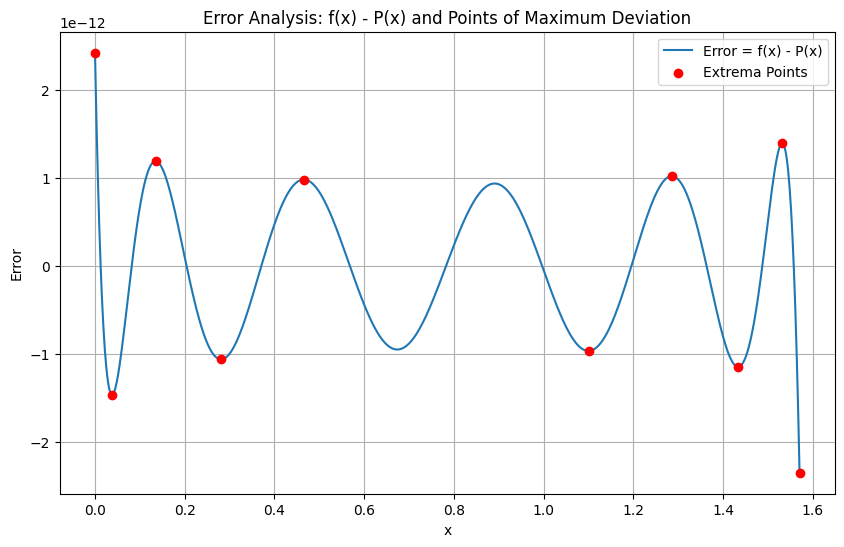

In [266]:

def plot_error_analysis(f, P, extrema_points, extrema_errors):
    # Generate points for plotting
    x_plot = np.linspace(bounds[0], bounds[1], 1000)
    error_plot = f(x_plot) - P(x_plot)
    
    # Plot f(x) - P(x) and mark the extrema points
    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, error_plot, label='Error = f(x) - P(x)')
    plt.scatter(extrema_points, f(extrema_points) - P(extrema_points), color='red', zorder=5, label='Extrema Points')
    plt.xlabel('x')
    plt.ylabel('Error')
    plt.title('Error Analysis: f(x) - P(x) and Points of Maximum Deviation')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_error_analysis(f, P, ex, exe)

In [267]:
def remez_step(f, x_points):
    n = len(x_points)-2
    
    # Step 2: Create the matrix A and vector b
    A = np.zeros((n+2, n+2))
    b = np.zeros(n+2)
    for i, x in enumerate(x_points):
        A[i, :-1] = [x**k for k in range(n+1)]
        A[i, -1] = (-1)**i
        b[i] = f(x)
    
    # Step 3: Solve the system of equations Ap = b
    p = np.linalg.solve(A, b)
    
    # Define the closure for polynomial evaluation
    def P(x):
        return np.polyval(p[:-1][::-1], x)
    
    return p[:-1][::-1], p[-1], P

In [268]:
p2, E2, P2 = remez_step(f, ex)
p2

array([ 1.71737185e-05, -2.45290448e-04,  7.00945577e-05,  8.27225227e-03,
        3.09303692e-05, -1.66675294e-01,  1.17583796e-06,  9.99999940e-01,
        5.01363104e-10])

In [269]:
ex2, exe2 = error_analysis(f, P2, bounds)
print(ex2.shape, exe2.shape)
print(max(exe2))

(10,) (10,)
2.4116637575843924e-09


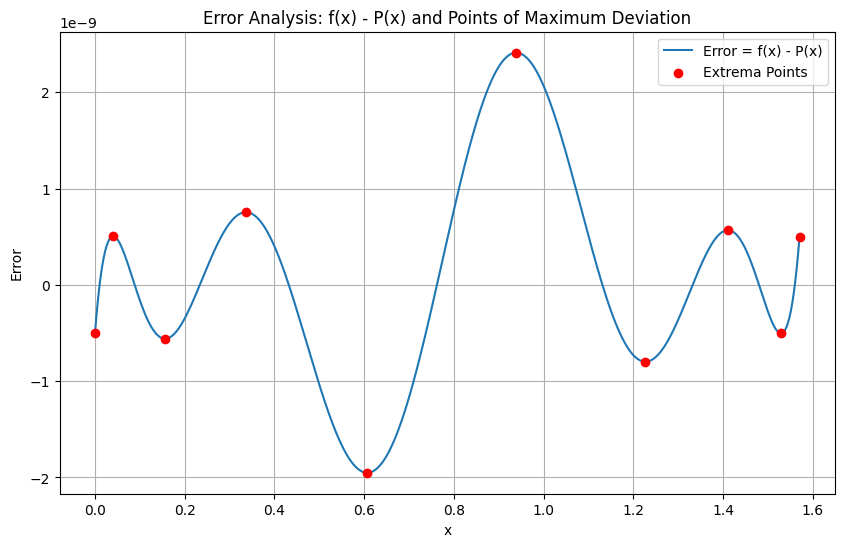

In [270]:
plot_error_analysis(f, P2, ex2, exe2)

In [271]:
p3, E3, P3 = remez_step(f, ex2)
p3

array([ 1.72058396e-05, -2.45704446e-04,  7.17636429e-05,  8.26913883e-03,
        3.39069428e-05, -1.66676735e-01,  1.49176583e-06,  9.99999916e-01,
        7.78343650e-10])

(10,) (10,)
9.914087328866117e-10


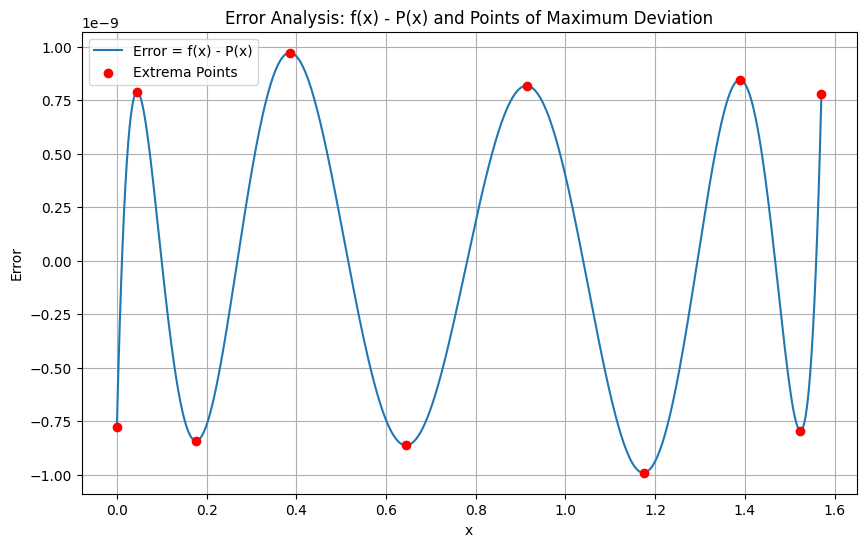

In [272]:
ex3, exe3 = error_analysis(f, P3, bounds)
print(ex3.shape, exe3.shape)
print(max(exe3))
plot_error_analysis(f, P3, ex3, exe3)

In [273]:
format_polynomial(p3)

'1.7205839570538653e-05x^8 -0.00024570444635781114x^7 +7.176364288048014e-05x^6 +0.008269138826766066x^5 +3.3906942770043264e-05x^4 -0.16667673455665638x^3 +1.491765834921741e-06x^2 +0.9999999156174182x +7.783436499070848e-10'

1.7209863008943345e-05x^8 -0.00024575124459624625x^7 +7.194649190849227e-05x^6 +0.008268794893899754x^5 +3.425379759410762e-05x^4 -0.16667692317020713x^3 +1.5422400957890642e-06x^2 +0.9999999106213322x +8.526477071446453e-10
(10,) (10,)
8.562690556601638e-10


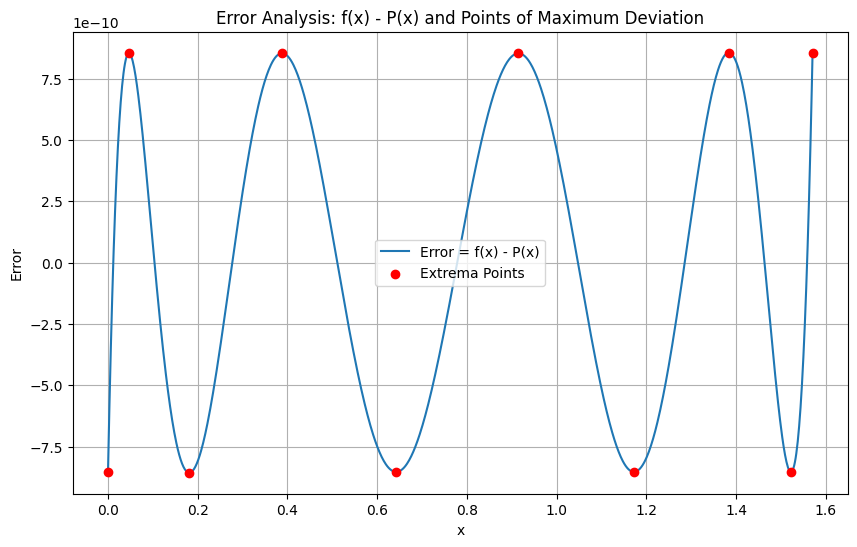

In [274]:
p4, E4, P4 = remez_step(f, ex3)
print(format_polynomial(p4))
ex4, exe4 = error_analysis(f, P4, bounds)
print(ex4.shape, exe4.shape)
print(max(exe4))
plot_error_analysis(f, P4, ex4, exe4)

In [6]:
def frenchify(string, one_word='oui', zero_word='non'):
    utf8_encoded_bytes = string.encode('utf-8')
    
    def to_french(bit):
        if bit == '1':
            return one_word
        else:
            return zero_word
            
    french_bytes = []
            
    for byte in utf8_encoded_bytes:
        # a string of length 8 containing characters '1' and '0'
        binary_string = bin(byte)[2:].zfill(8)

        french_byte = ' '.join(to_french(bit) for bit in binary_string)
        french_bytes.append(french_byte)
        
    
    # Join the oui/non strings with commas and add a period at the end
    return (', '.join(french_bytes) + '.').capitalize()
    
# Example usage
frenchify("Hello!")


'Non oui non non oui non non non, non oui oui non non oui non oui, non oui oui non oui oui non non, non oui oui non oui oui non non, non oui oui non oui oui oui oui, non non oui non non non non oui.'

In [8]:
import re

def defrenchify(frenchified_string, one_word='oui', zero_word='non'):
    # Create a regex pattern that is case-insensitive and matches the specified one_word and zero_word
    pattern = re.compile(rf"({one_word}|{zero_word})", re.IGNORECASE)
    
    binary_strings = []
    
    # Find all matches of the one_word and zero_word
    for match in pattern.findall(frenchified_string):
        # Convert the matched words to '1' or '0'
        bit = '1' if match.lower() == one_word.lower() else '0'
        binary_strings.append(bit)
    
    # Group binary strings into bytes
    bytes_list = [''.join(binary_strings[i:i+8]) for i in range(0, len(binary_strings), 8)]
    
    # Convert binary strings to bytes and decode from UTF-8
    decoded_string = ''.join([chr(int(byte, 2)) for byte in bytes_list if len(byte) == 8])
    
    return decoded_string

# Example usage:
result = defrenchify('Non oui non non oui non non non, non oui oui non non oui non oui, non oui oui non oui oui non non, non oui oui non oui oui non non, non oui oui non oui oui oui oui, non non oui non non non non oui.')
print(result)


Hello!


In [9]:
frenchify("ABC")

'Non oui non non non non non oui, non oui non non non non oui non, non oui non non non non oui oui.'

In [10]:
defrenchify('Non oui non non non non non oui, non oui non non non non oui non, non oui non non non non oui oui.')

'ABC'

In [12]:
frenchify("This sentence is comprised of French words.")


'Non oui non oui non oui non non, non oui oui non oui non non non, non oui oui non oui non non oui, non oui oui oui non non oui oui, non non oui non non non non non, non oui oui oui non non oui oui, non oui oui non non oui non oui, non oui oui non oui oui oui non, non oui oui oui non oui non non, non oui oui non non oui non oui, non oui oui non oui oui oui non, non oui oui non non non oui oui, non oui oui non non oui non oui, non non oui non non non non non, non oui oui non oui non non oui, non oui oui oui non non oui oui, non non oui non non non non non, non oui oui non non non oui oui, non oui oui non oui oui oui oui, non oui oui non oui oui non oui, non oui oui oui non non non non, non oui oui oui non non oui non, non oui oui non oui non non oui, non oui oui oui non non oui oui, non oui oui non non oui non oui, non oui oui non non oui non non, non non oui non non non non non, non oui oui non oui oui oui oui, non oui oui non non oui oui non, non non oui non non non non non, non oui n

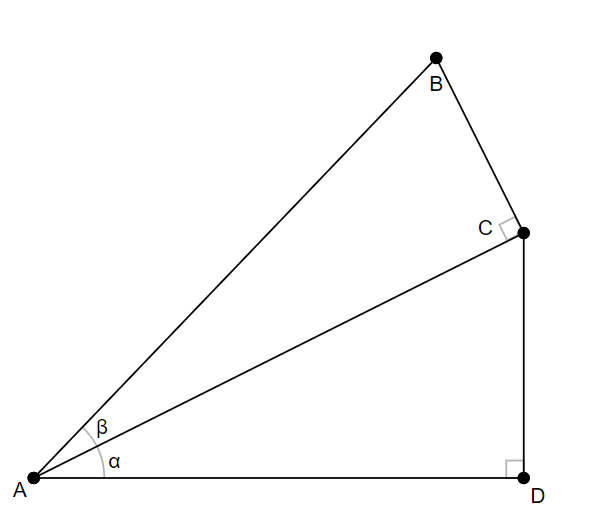

In [6]:
from PIL import Image
from glob import glob
from IPython.display import Image as IPImage, display

frames = []
for screenshot_filename in glob('images/s_[0-9][0-9].png'):
    screenshot = Image.open(screenshot_filename)
    image = screenshot.crop((280, 260, 880 + 1, 780 + 1))
    image_filename = screenshot_filename.replace('s_', 'aa_')
    image.save(image_filename)
    frames.append(image)

animation = frames[0]
animation.save('images/animation.gif', save_all=True, append_images=frames[1:], duration=1000, loop=0)

IPImage(filename='images/animation.gif')

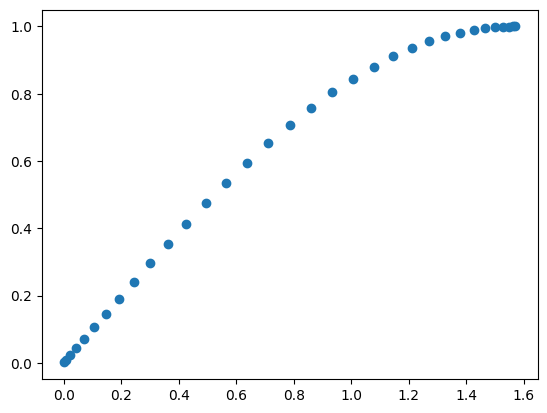

In [21]:
import numpy as np
from scipy.optimize import least_squares

# Suppose x_data and y_data are your N sampled points
k = 5
x_data = nodes = chebyshev_nodes(a=0, b=np.pi/2, n=32)
y_data = np.sin(x_data)
plt.scatter(x_data, y_data)

In [22]:
# Define the model function
def model(params, x):
    p = params[:k+1]  # Coefficients of P
    q = np.concatenate(([1], params[k+1:]))  # Coefficients of Q, fixing q0 = 1 for stability
    P_x = np.polyval(p[::-1], x)
    Q_x = np.polyval(q[::-1], x)
    return P_x / Q_x

# Define the objective function
def objective(params, x, y):
    return model(params, x) - y

# Initial guess for parameters
params_initial = np.zeros(2*k + 1)

# Perform the optimization
result = least_squares(objective, params_initial, args=(x_data, y_data))

# Extract optimized parameters
optimized_params = result.x
optimized_params

array([ 1.59075099e-11,  9.99999998e-01,  2.04576160e-02, -1.34403536e-01,
       -2.09800975e-03,  3.36220203e-03,  2.04575747e-02,  3.22634544e-02,
        1.31031993e-03,  4.08862349e-04,  4.44778079e-05])

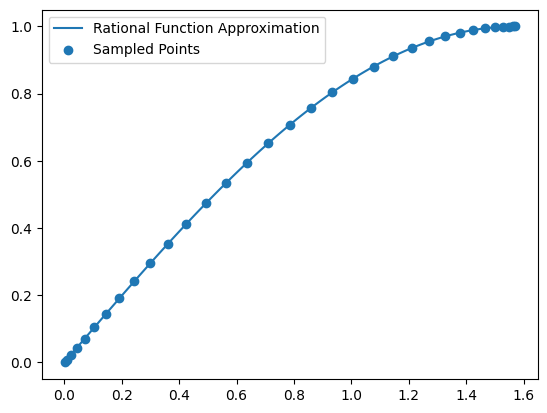

In [23]:
x_fill = np.linspace(0, np.pi/2, 100)
y_fill = np.array([ model(optimized_params, x) for x in x_fill ])
y_true = np.array([ np.sin(x) for x in x_fill ])
plt.plot(x_fill, y_fill, label='Rational Function Approximation')
plt.scatter(x_data, y_data, label='Sampled Points')
plt.legend()

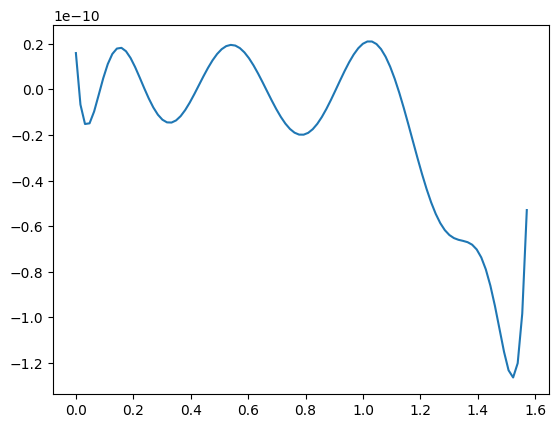

In [59]:
plt.plot(x_fill, y_fill-y_true)

In [111]:
from IPython.display import display, Math

def format_rational_function_to_latex(p_coeffs, q_coeffs):
    """
    Formats the given coefficients of P(x) and Q(x) into a LaTeX string.
    
    Parameters:
    - p_coeffs: Coefficients of the numerator polynomial P(x).
    - q_coeffs: Coefficients of the denominator polynomial Q(x).
    
    Returns:
    A LaTeX string representation of the rational function P(x)/Q(x).
    """
    def format_poly(coeffs):
        # Generate each term of the polynomial
        terms = []
        degree = len(coeffs) - 1
        for i, coeff in enumerate(coeffs):
            if coeff != 0:  # Only add non-zero terms
                # Format the coefficient
                coeff_str = '{:.9f}'.format(coeff).rstrip('0').rstrip('.') if coeff not in [-1, 1] or (degree - i) == 0 else '-' if coeff == -1 else ''

                # skip zero terms
                if coeff_str == '0':
                    pass
                    #continue
                    
                # Format the variable part    
                if (degree - i) > 0:
                    #if coeff_str == '1':
                    #    coeff_str = ''

                    x_str = 'x' if (degree - i) == 1 else 'x^{}'.format(degree - i)
                else:
                    x_str = ''
                terms.append(coeff_str + x_str)
        return ' + '.join(terms).replace('+ -', '- ')

    # Format the numerator and denominator
    p_str = format_poly(p_coeffs)
    q_str = format_poly(q_coeffs)

    # Combine to form the rational function string
    latex_str = f'\\frac{{{p_str}}}{{{q_str}}}'
    
    return latex_str


def display_rational_function(params, k):
    """
    Display a rational function given its parameters.

    Parameters:
    - params: Combined coefficients of P(x) and Q(x) in descending order.
    - k: The order of polynomials P(x) and Q(x).
    """
    p = params[:k+1]  # Coefficients of P
    q = np.concatenate(([1], params[k+1:]))  # Coefficients of Q, fixing q0 = 1 for stability

    # Use the existing function to format to LaTeX
    latex_str = format_rational_function_to_latex(p[::-1], q[::-1])
    
    # Display using Math for LaTeX rendering
    display(Math(latex_str))


display_rational_function(optimized_params, k)


<IPython.core.display.Math object>

In [54]:
len(optimized_params)

11

In [35]:
def model(params, x):
    p = params[:k+1]  # Coefficients of P
    print(p)
    q = np.concatenate(([1], params[k+1:]))  # Coefficients of Q, fixing q0 = 1 for stability
    print(q)
    P_x = np.polyval(p[::-1], x)
    Q_x = np.polyval(q[::-1], x)
    print(P_x, '/', Q_x)
    return P_x / Q_x

In [66]:
e = np.e
pi = np.pi

int(e ** (pi *np.sqrt(163)))

262537412640767712

In [70]:
import mpmath

# Set the precision (number of digits)
mpmath.mp.dps = 50  # dps is decimal places, adjust as needed

# Calculate e^(pi*sqrt(163))
result = mpmath.exp(mpmath.pi * mpmath.sqrt(163))

print(result)


262537412640768743.99999999999925007259719818568888


In [74]:
float(262537412640768744 - result)

7.499274028018143e-13

In [81]:
import mpmath

# Set the desired precision (number of digits)
mpmath.mp.dps = 128  # Adjust as needed for your application

# Define matrix A and vector b
A = mpmath.matrix([[2, 3], [1, 2]])
b = mpmath.matrix([4, 3])

# Solve Ax = b for x
x = mpmath.lu_solve(A, b)

print("Solution x:", x)


Solution x: [-1.0]
[ 2.0]


In [89]:
pi2 = mpmath.findroot(mpmath.sin, 3)
pi2

mpf('3.1415926535897932384626433832795028841971693993751058209749445923078164062862089986280348253421170679821480865132823066470938446096')

In [90]:
dict(zip(['negative', 'mantissa', 'exponent', 'bitcount'], pi2._mpf_))

{'negative': 0,
 'mantissa': 1141715598295827886284146596318906581494752591100903810227730751823731837176045890474041405000406875230839359923319856739557922844846191,
 'exponent': -447,
 'bitcount': 449}

taylor coefficients: [0.0, 1.0, 0.0, -0.16666666666666666666666666666666666666666666666667, 0.0, 0.0083333333333333333333333333333333333333333333333333, 0.0, -0.0001984126984126984126984126984126984126984126984127, 0.0, 0.0000027557319223985890652557319223985890652557319223986, 0.0]
pade coefficients: [0.0, 1.0, 0.0, -0.13383838383838383838383838383838383838383838383838, 0.0, 0.0033128908128908128908128908128908128908128908128908] [1.0, 0.0, 0.032828282828282828282828282828282828282828282828283, 0.0, 0.00045093795093795093795093795093795093795093795093795, 0.0]


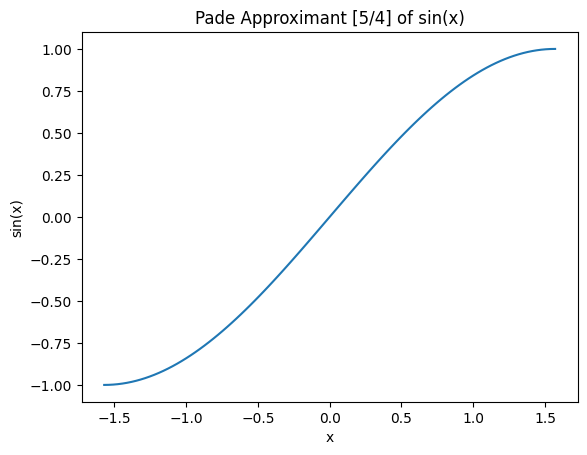

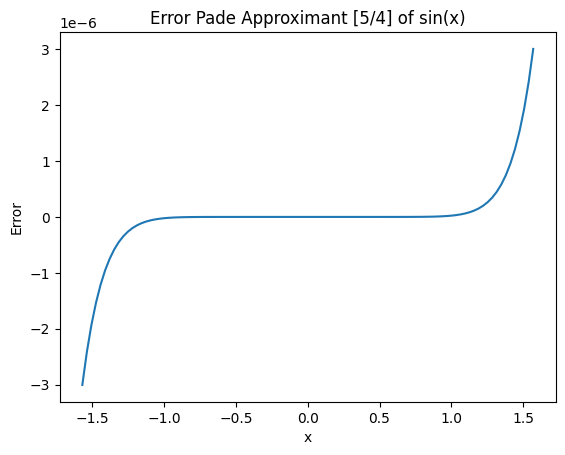

In [146]:
#from mpmath import *
import math
mpmath.mp.dps = 50
mpmath.mp.pretty = True

one = mpmath.mpf(1)

#def f(x):
#    return sqrt((one + 2*x)/(one + x))
f = mpmath.sin

p_degree = 5
q_degree = 4
taylor_degree = p_degree + q_degree + 1

a = mpmath.taylor(f, 0, taylor_degree)
print('taylor coefficients:', a)

#p, q = mpmath.pade(a, 3, 3)
p, q = mpmath.pade(a, p_degree, p_degree)
print('pade coefficients:', p, q)

xs = np.linspace(-math.pi/2, +math.pi/2, num=100)

@np.vectorize
def pade_approximant_sin(x):
    return mpmath.polyval(p[::-1], x) / mpmath.polyval(q[::-1], x)

ys = pade_approximant_sin(xs)
plt.plot(xs, ys)
plt.title(f"Pade Approximant [{p_degree}/{q_degree}] of sin(x)")
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

ys2 = [ mpmath.sin(x) for x in xs ]
error = ys - ys2
plt.plot(xs, error)
plt.title(f"Error Pade Approximant [{p_degree}/{q_degree}] of sin(x)")
plt.xlabel('x')
plt.ylabel('Error');

In [147]:
# floats = lambda zs: [ float(z) for z in zs ]
# display_rational_function(floats(p)+[1]+floats(q), k=3)
# why is this wrong?

In [148]:
def format_poly(coeffs):
    # Generate each term of the polynomial
    terms = []
    degree = len(coeffs) - 1
    for i, coeff in enumerate(coeffs):
        if coeff != 0:  # Only add non-zero terms
            # Format the coefficient
            coeff_str = str(coeff).rstrip('0').rstrip('.') if coeff not in [-1, 1] or (degree - i) == 0 else '-' if coeff == -1 else ''

            # skip zero terms
            if coeff_str == '0':
                pass
                #continue
                
            # Format the variable part    
            if (degree - i) > 0:
                #if coeff_str == '1':
                #    coeff_str = ''

                x_str = 'x' if (degree - i) == 1 else 'x^{}'.format(degree - i)
            else:
                x_str = ''
            terms.append(coeff_str + x_str)
    return ' + '.join(terms).replace('+ -', '- ')



In [149]:
def format_rational(p_coeff, q_coeff):
    p_str = format_poly(p_coeff[::-1])
    q_str = format_poly(q_coeff[::-1])
    latex_str = f'\\frac{{{p_str}}}{{{q_str}}}'
    return Math(latex_str)

format_rational(p, q)

<IPython.core.display.Math object>

In [150]:
total_numbers = 10**4
identical_digits_numbers = 10
total_numbers - identical_digits_numbers


9990

In [151]:
math.log2(9990)

13.286268962679781